# Comparing neural-network performance: initial vs. optimized design (Gaussian impulse)

Compares how well a CNN reads out the applied force from sensor data before
vs. after the structure's design has been co-optimized, for the simulated
(Gaussian impulse) case.

Trains a fresh `TimeSeriesCNN` per design (no pretrained/pickled weights),
on one fixed train/test split, normalized with a **single scaler fit on the
initial design's data and reused for the optimized design** (matching the
original research notebook's convention), so the comparison is on equal
footing.

In [1]:
from pathlib import Path
import sys

import numpy as np
import jax
import jax.numpy as jnp
import optax
from jaxopt import OptaxSolver
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

from neural_networks import TimeSeriesCNN, minmax_scaler

# Default setting
import matplotlib as mpl
import matplotlib
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]

sim_train = np.load(DATA_DIR / "gaussian_impulse_nn_comparison.npz")    # input/output pairs

## Train a CNN per design and compare test loss

Initial and optimized designs are driven by identical force samples (via
`forward_simulation`), so they share one train/test split and one scaler
(fit on the initial design's training data).

In [2]:
def make_split(n_samples, seed=0, test_frac=0.1):
    key = jax.random.PRNGKey(seed)
    test_n = max(1, int(round(n_samples * test_frac)))
    test_idx = jax.random.randint(key, shape=(test_n,), minval=0, maxval=n_samples)
    mask = jnp.ones(n_samples, dtype=bool).at[test_idx].set(False)
    return mask, test_idx


def train_and_track(input_data, output_data, train_mask, test_idx, scaler, iters=1000, lr=1e-2, eval_every=5, seed=0):
    train_x, train_y = input_data[train_mask], output_data[train_mask]
    test_x, test_y = input_data[test_idx], output_data[test_idx]

    train_xn, train_yn = scaler.transform(train_x, train_y)
    test_xn, test_yn = scaler.transform(test_x, test_y)

    model = TimeSeriesCNN(output_features=output_data.shape[-1])
    params = model.init(jax.random.PRNGKey(seed), train_xn)

    def loss_fn(params, data):
        x, y = data
        pred = model.apply(params, x)
        return jnp.mean((pred - y) ** 2)

    solver = OptaxSolver(opt=optax.adam(lr), fun=loss_fn, maxiter=iters)
    state = solver.init_state(params, (train_xn, train_yn))

    history = []
    for i in range(iters):
        params, state = solver.update(params, state, (train_xn, train_yn))
        if i % eval_every == 0 or i == iters - 1:
            history.append((i, float(loss_fn(params, (test_xn, test_yn)))))

    pred_test = model.apply(params, test_xn)
    _, pred_test_org = scaler.inverse_transform(test_xn, pred_test)
    return history, test_x, test_y, pred_test_org

In [3]:
sim_output = jnp.asarray(sim_train["output_data"])
sim_input_initial = jnp.asarray(sim_train["input_data_initial"])
sim_input_optimized = jnp.asarray(sim_train["input_data_optimized"])
sim_mask, sim_test_idx = make_split(sim_output.shape[0])

# One scaler, fit on the initial design's training data, reused for optimized.
sim_scaler = minmax_scaler(sim_input_initial[sim_mask], sim_output[sim_mask])

sim_hist_initial, sim_test_x_i, sim_test_y_i, sim_pred_i = train_and_track(
    sim_input_initial, sim_output, sim_mask, sim_test_idx, sim_scaler
)
sim_hist_optimized, sim_test_x_o, sim_test_y_o, sim_pred_o = train_and_track(
    sim_input_optimized, sim_output, sim_mask, sim_test_idx, sim_scaler
)

print(f"initial final test loss:   {sim_hist_initial[-1][1]:.4e}")
print(f"optimized final test loss: {sim_hist_optimized[-1][1]:.4e}")

(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)


initial final test loss:   1.0928e-03
optimized final test loss: 4.3984e-04


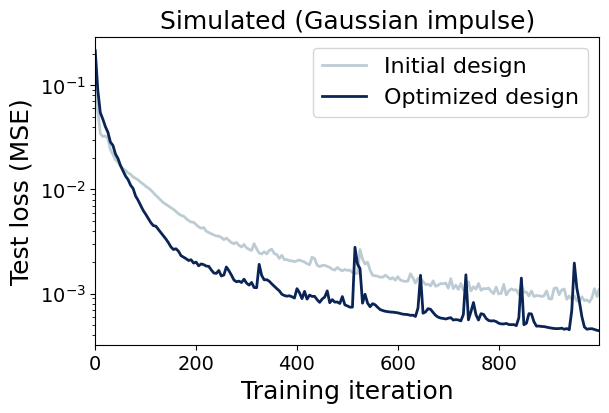

In [4]:
it_i, loss_i = zip(*sim_hist_initial)
it_o, loss_o = zip(*sim_hist_optimized)

plt.figure(figsize=(6.5, 4))
plt.semilogy(it_i, loss_i, color=COLORS[1], label="Initial design")
plt.semilogy(it_o, loss_o, color=COLORS[2], label="Optimized design")
plt.xlabel("Training iteration")
plt.ylabel("Test loss (MSE)")
plt.title("Simulated (Gaussian impulse)")
plt.legend()
plt.show()

## Example predictions

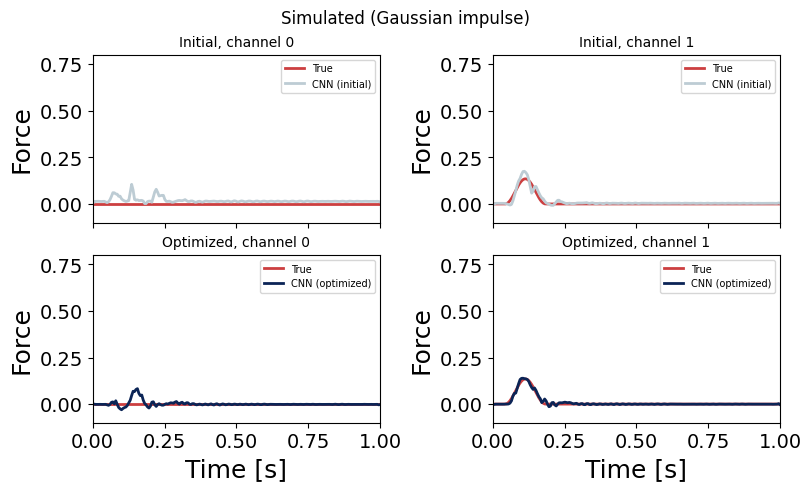

In [5]:
def plot_prediction_examples(test_y_init, pred_init, test_y_opt, pred_opt, title, sample=0):
    n_channels = np.asarray(test_y_init).shape[-1]
    time = np.linspace(0.0, 1.0, np.asarray(test_y_init).shape[1])
    fig, axes = plt.subplots(2, n_channels, figsize=(4 * n_channels, 4.8), sharex=True, constrained_layout=True)
    if n_channels == 1:
        axes = axes.reshape(2, 1)
    for ch in range(n_channels):
        axes[0, ch].plot(time, -np.asarray(test_y_init)[sample, :, ch], color=COLORS[0], label="True")
        axes[0, ch].plot(time, -np.asarray(pred_init)[sample, :, ch], color=COLORS[1], label="CNN (initial)")
        axes[0, ch].set_title(f"Initial, channel {ch}", fontsize=10)
        axes[1, ch].plot(time, -np.asarray(test_y_opt)[sample, :, ch], color=COLORS[0], label="True")
        axes[1, ch].plot(time, -np.asarray(pred_opt)[sample, :, ch], color=COLORS[2], label="CNN (optimized)")
        axes[1, ch].set_title(f"Optimized, channel {ch}", fontsize=10)
        axes[1, ch].set_xlabel("Time [s]")
    for ax in axes.ravel():
        ax.set_ylabel("Force")
        ax.set_ylim(-0.1, 0.8)
        ax.legend(loc="upper right", fontsize=7)
    fig.suptitle(title, fontsize=12)
    return fig


plot_prediction_examples(sim_test_y_i, sim_pred_i, sim_test_y_o, sim_pred_o, "Simulated (Gaussian impulse)")
plt.show()